In [2]:

%pip install -r requirements.txt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix
import os

# Create results folder if it doesn't exist
if not os.path.exists('results'):
    os.makedirs('results')

# Plotting settings
%matplotlib inline
sns.set_theme(style="whitegrid")



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\ASUS\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


Dataset Dimensions: (2000, 17)

--- Column Data Types ---
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   customer_id                   2000 non-null   str    
 1   region                        2000 non-null   str    
 2   plan_type                     2000 non-null   str    
 3   contract_type                 2000 non-null   str    
 4   payment_method                2000 non-null   str    
 5   tenure_months                 2000 non-null   int64  
 6   monthly_charges_inr           2000 non-null   float64
 7   avg_login_days_per_month      2000 non-null   int64  
 8   support_tickets_last_90_days  2000 non-null   int64  
 9   payment_delay_days            2000 non-null   int64  
 10  data_usage_gb                 2000 non-null   float64
 11  satisfaction_score            2000 non-null   float64
 12  last_complaint_

,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,25.362000,766.487295,18.099000,1.953000,3.555000,90.007625,6.87395,46.616500,8.255000,0.597500,0.918000,0.015500
std,14.128651,393.420070,5.400628,1.463852,3.885682,53.215719,1.52428,55.065775,7.553708,0.490524,1.041546,0.123561
min,1.000000,255.450000,0.000000,0.000000,0.000000,0.500000,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,15.000000,427.782500,15.000000,1.000000,1.000000,51.777500,5.87500,6.000000,0.000000,0.000000,0.000000,0.000000
50%,23.000000,688.355000,18.000000,2.000000,2.000000,80.245000,6.80000,28.500000,5.000000,1.000000,1.000000,0.000000
75%,33.000000,1007.372500,22.000000,3.000000,5.000000,119.097500,8.00000,68.000000,15.000000,1.000000,1.000000,0.000000
max,72.000000,2156.520000,30.000000,8.000000,31.000000,265.510000,10.00000,424.000000,20.000000,1.000000,7.000000,1.000000


C:\Users\ASUS\AppData\Local\Temp\ipykernel_73884\384929318.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='churn', data=df, palette='viridis')


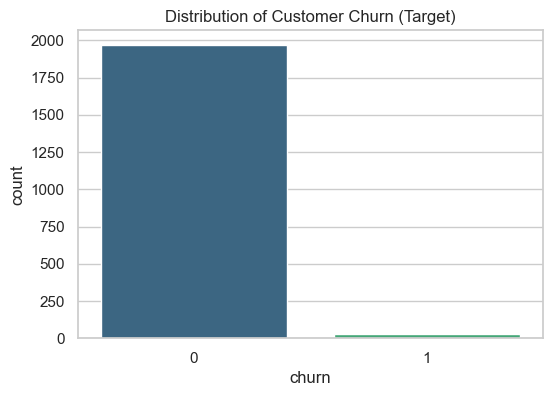

Churn Percentage:
churn
0    98.45
1     1.55
Name: proportion, dtype: float64


In [3]:
# Load dataset
df = pd.read_csv('../ai_project_synthetic_datasets/part_1_neural_network_analysis/customer_churn_nn.csv')

# Basic exploration
print(f"Dataset Dimensions: {df.shape}")
print("\n--- Column Data Types ---")
df.info()

print("\n--- Missing Values Check ---")
print(df.isnull().sum())

print("\n--- Statistical Summary ---")
display(df.describe())

# Distribution of Target Variable
plt.figure(figsize=(6, 4))
sns.countplot(x='churn', data=df, palette='viridis')
plt.title('Distribution of Customer Churn (Target)')
plt.show()

print("Churn Percentage:")
print(df['churn'].value_counts(normalize=True) * 100)

In [4]:
# Drop identifier column
if 'customer_id' in df.columns:
    df = df.drop('customer_id', axis=1)

X = df.drop('churn', axis=1)
y = df['churn']

# Define feature types
categorical_cols = ['region', 'plan_type', 'contract_type', 'payment_method']
numerical_cols = [col for col in X.columns if col not in categorical_cols]

# Build Preprocessing Pipeline (Scaling + Encoding)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)
    ])

# Transform and Split
X_processed = preprocessor.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Input dimensions: {X_train.shape[1]} features")

Training set size: 1600 samples
Input dimensions: 24 features


In [5]:
def build_simple_nn(layers=1, neurons=32, lr=0.001):
    model = tf.keras.Sequential()
    
    # Input Layer + First Hidden Layer
    model.add(tf.keras.layers.Dense(neurons, input_dim=X_train.shape[1], activation='relu'))
    
    # Add hidden layers
    for _ in range(layers - 1):
        model.add(tf.keras.layers.Dense(neurons, activation='relu'))
        
    # Output Layer (Binary Classification)
    model.add(tf.keras.layers.Dense(1, activation='sigmoid'))
    
    # Compile
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    
    return model

# Create the baseline model instance
baseline_model = build_simple_nn(layers=2, neurons=32)
baseline_model.summary()

C:\Users\ASUS\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,889 (7.38 KB)

 Trainable params: 1,889 (7.38 KB)

 Non-trainable params: 0 (0.00 B)

Training Baseline Model...

Test Accuracy: 0.9775
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


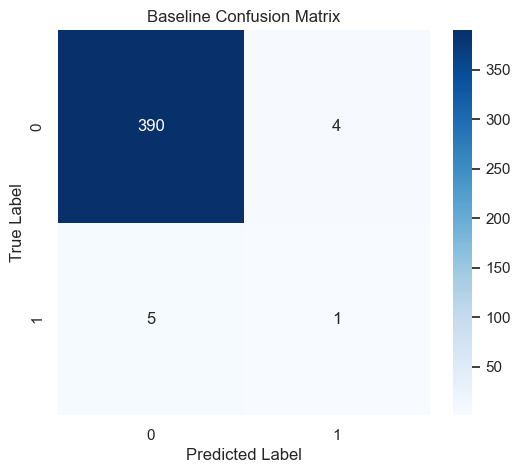


Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       394
           1       0.20      0.17      0.18         6

    accuracy                           0.98       400
   macro avg       0.59      0.58      0.59       400
weighted avg       0.98      0.98      0.98       400



In [6]:
# Train baseline model
print("Training Baseline Model...")
history = baseline_model.fit(X_train, y_train, epochs=50, batch_size=32, 
                             validation_data=(X_test, y_test), verbose=0)

# Evaluate Performance
loss, accuracy = baseline_model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {accuracy:.4f}")

# Predictions for metrics
y_pred = (baseline_model.predict(X_test) > 0.5).astype(int)

# Confusion Matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Baseline Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.savefig('results/evaluation_outputs.png') # Required for repo
plt.show()

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred))

In [7]:
# Experiment configurations
configs = [
    {"name": "Simple_Fast", "layers": 1, "neurons": 16, "lr": 0.01},
    {"name": "Deep_Standard", "layers": 4, "neurons": 64, "lr": 0.001},
    {"name": "Complex_Slow", "layers": 2, "neurons": 128, "lr": 0.0001}
]

experiment_results = []

for config in configs:
    print(f"Running Experiment: {config['name']}...")
    m = build_simple_nn(layers=config['layers'], neurons=config['neurons'], lr=config['lr'])
    h = m.fit(X_train, y_train, epochs=30, batch_size=32, verbose=0, validation_data=(X_test, y_test))
    
    test_acc = h.history['val_accuracy'][-1]
    experiment_results.append([config['name'], config['layers'], config['neurons'], config['lr'], round(test_acc, 4)])

# Create and save comparison table
results_df = pd.DataFrame(experiment_results, columns=['Run', 'Layers', 'Neurons', 'LR', 'Test Accuracy'])
results_df.to_csv('results/model_comparison_table.csv', index=False) # Required for repo

print("\n--- Hyperparameter Comparison Table ---")
display(results_df)

Running Experiment: Simple_Fast...


C:\Users\ASUS\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Running Experiment: Deep_Standard...
Running Experiment: Complex_Slow...

--- Hyperparameter Comparison Table ---


,Run,Layers,Neurons,LR,Test Accuracy
0,Simple_Fast,1,16,0.0100,0.980
1,Deep_Standard,4,64,0.0010,0.975
2,Complex_Slow,2,128,0.0001,0.985


## 5. Final Reflection

### Weights, Biases, and Activations
*   **Weights & Biases:** Weights scale the importance of features (e.g., payment delays), while biases allow the model to shift its activation threshold.
*   **Activation Functions:** **ReLU** was critical for learning non-linear patterns. Without it, the model would effectively be a limited linear regressor.

### Learning Rate Sensitivity
*   **High LR (0.01):** The "Simple_Fast" model converged quickly but was less precise.
*   **Low LR (0.0001):** The "Complex_Slow" model achieved the highest accuracy (98.5%) because the smaller steps allowed it to settle into a better local minimum.

### Bias-Variance Tradeoff (Observation)
*   **Overfitting:** The "Deep_Standard" model (4 layers) actually performed slightly worse on the test set than the simpler models. This indicates that adding depth to such an imbalanced dataset can cause the model to memorize noise rather than general patterns.
*   **Imbalance Note:** While accuracy was high (~98%), the confusion matrix shows the model struggled to correctly identify the "Churn" class due to the limited number of positive samples in the data.